# Rain, rivers and tide at Prince Rupert — scoping a water-quality mooring

**Site:** Prince Rupert / Chatham Sound, BC — 54.317 N, 130.324 W.
**Window:** 15 September – 16 November 2024, the front half of the north-coast wet season.

I am costing a year-long water-quality mooring in Prince Rupert harbour and I need to know,
*before* I ask for ship time, what environmental drivers I can already get for free and how
they relate to each other. The specific question behind the deployment is:

> **Does rainfall on the north coast show up in the harbour as a freshet signal, and how does
> that interact with the tide?**

Prince Rupert is one of the wettest places in Canada and has a spring tide range near 7.5 m,
so both terms are large. If the freshwater signal is already visible in public archives, the
mooring is confirmatory and can be small. If it is not, the mooring is the only way to see it —
and I need to say so in the proposal with numbers attached.

This notebook uses `omnisea` to pull the archives, join them onto one time axis, and answer
that. Everything below hits live APIs. I check a few of the numbers against the upstream
services directly, because a silently wrong number is worse than a missing one.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import omnisea

# Third-party deprecations only. omnisea's own warnings stay on -- they are how it tells you
# a join is about to be wrong.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# A public server that accepts a connection and then never answers costs `read` seconds per
# attempt, and omnisea retries once. Bounding it keeps a bad day at one institution cheap.
omnisea.set_timeout(connect=6, read=45)

PRINCE_RUPERT = omnisea.Site(54.317, -130.324, "Prince Rupert", radius_km=50)
WINDOW = ("2024-09-15", "2024-11-16")
TZ = "America/Vancouver"          # local time on this coast; PDT until 3 Nov 2024, then PST

print(f"omnisea {omnisea.__version__}, {len(omnisea.sources())} sources, "
      f"{len(omnisea.providers())} organizations")

omnisea 0.1.0, 18 sources, 5 organizations


## 1. What is within 50 km, and how big is it?

`discover()` is a survey: it asks every source what stations it has near the site over the
window, and returns row-count estimates without downloading anything. That matters here —
an unbounded ECCC hourly query is hundreds of millions of rows.

I am deliberately asking *all* sources, not a shortlist, because the point of this step is to
find out what I do not already know about.

In [2]:
catalog = omnisea.discover(sites=PRINCE_RUPERT, time=WINDOW)
print(catalog)

<Catalog: 91 station(s) from 9 source(s), ~109,582 rows>
                       source                       station_id                            name  distance_km  n_rows_est                          variables
                    dfo_tides                            09354                   Prince Rupert         0.00        6200 water_surface_height_above_refere…
         eccc_climate_monthly                          1066492            PRINCE RUPERT R PARK         1.98           3 air_temperature, days_with_valid_…
         eccc_climate_monthly                          1066488         PRINCE RUPERT MONT CIRC         2.24           3 air_temperature, days_with_valid_…
           eccc_climate_daily                          1066488         PRINCE RUPERT MONT CIRC         2.24          62 air_temperature, integral_wrt_tim…
                    dfo_tides                            09360                       Seal Cove         3.28        6200 water_surface_height_above_refere…
         eccc

Ninety-one stations across nine collections. Rolled up by organization, so I can see who has
what and roughly how much of it:

In [3]:
by_source = (catalog.frame
             .groupby(["provider", "source"])
             .agg(stations=("station_id", "size"),
                  nearest_km=("distance_km", "min"),
                  est_rows=("n_rows_est", "sum"))
             .sort_values("nearest_km"))
print(by_source.to_string())

                                        stations  nearest_km  est_rows
provider source                                                       
dfo      dfo_tides                            30    0.000000     49104
eccc     eccc_climate_monthly                 16    1.984921        48
         eccc_climate_daily                    7    2.235074       434
         eccc_climate                          4    8.552948      5952
erddap   erddap_tabledap                       6    9.007555     53568
eccc     eccc_hydrometric_annual               7   12.514520         7
         eccc_hydrometric_annual_peaks         7   12.514520         7
         eccc_hydrometric_daily                7   12.514520       441
         eccc_hydrometric_monthly              7   12.514520        21


And the sources that had nothing to offer say *why*, which is the answer I actually need —
"no station here" and "this collection does not go back that far" are different facts:

In [4]:
for source, note in sorted(catalog.notes.items()):
    print(f"{source}\n    {note}\n")

eccc_ahccd_annual
    covers 1840-01-01 to 2020-12-31; the requested window starts 2024-09-15, after the last data this collection publishes

eccc_ahccd_monthly
    covers 1840-01-01 to 2020-12-31; the requested window starts 2024-09-15, after the last data this collection publishes

eccc_ahccd_seasonal
    covers 1840-01-01 to 2020-12-31; the requested window starts 2024-09-15, after the last data this collection publishes

eccc_hydrometric
    holds only the last ~30 days (back to 2026-07-28); the requested window ends 2024-11-16 and is entirely outside it

eccc_swob
    holds only the last ~30 days (back to 2026-07-28); the requested window ends 2024-11-16 and is entirely outside it

eccc_swob_marine
    holds only the last ~30 days (back to 2026-07-28); the requested window ends 2024-11-16 and is entirely outside it



Three ECCC realtime collections (`swob`, `swob_marine`, `hydrometric`) keep about 30 days, so a
2024 window is simply outside them; the AHCCD homogenized series stop in 2020. None of that is
an error, and none of it would have been visible from an empty result.

## 2. The freshet gauges: seven rivers, no data

The catalogue lists hydrometric stations within 50 km — Kloiya River, Diana Creek, Rainbow Lake,
Boneyard Creek, Thulme River, Union Creek, Brown Creek. Discharge from Kloiya River would be the
obvious freshwater proxy for the inner harbour. Every one of them is estimated at 63 rows for my
window, which is exactly one row per day: a suspiciously round number.

In [5]:
rivers = omnisea.discover(sites=PRINCE_RUPERT, time=WINDOW, providers="eccc_hydrometric_daily")
print(rivers.frame[["station_id", "name", "distance_km", "n_rows_est", "first", "last"]]
      .to_string(index=False))

station_id                                     name  distance_km  n_rows_est first last
   08EG016          KLOIYA RIVER NEAR PRINCE RUPERT    12.514520          63  None None
   08EG015           DIANA CREEK NEAR PRINCE RUPERT    14.362025          63  None None
   08EG014          RAINBOW LAKE NEAR PRINCE RUPERT    20.554609          63  None None
   08EG013 BONEYARD CREEK AT OUTLET OF RAINBOW LAKE    20.574720          63  None None
   08EG004           THULME RIVER NEAR PORT SIMPSON    28.780994          63  None None
   08DB002            UNION CREEK NEAR PORT SIMPSON    38.622546          63  None None
   08EG001          BROWN CREEK NEAR PORT ESSINGTON    45.022398          63  None None


`first` and `last` are `None` for all seven — the station list publishes no period of record, so
`n_rows_est` is just *days in window*, not a claim about data. Fetch them and see:

In [6]:
river_tree = omnisea.fetch(sites=PRINCE_RUPERT, time=WINDOW,
                           providers="eccc_hydrometric_daily", on_error="collect")
print("nodes with data:", [n.path for n in river_tree.subtree if n.dataset.data_vars])
print()
print(omnisea.citation(river_tree))

nodes with data: []

No data was retrieved. Why:

  NOTE: these stations were matched but returned no rows: eccc_hydrometric_daily/08DB002, eccc_hydrometric_daily/08EG001, eccc_hydrometric_daily/08EG004, eccc_hydrometric_daily/08EG013, eccc_hydrometric_daily/08EG014, eccc_hydrometric_daily/08EG015, eccc_hydrometric_daily/08EG016


Nothing. `citation()` is the thing that tells you — it lists stations that matched but returned
no rows, which is precisely the failure mode that gets published by accident. Worth knowing:
`fetch()` itself was silent about this. No warning, no exception, just a tree with no nodes.

Before I believe it, I check upstream directly. ECCC's own station metadata carries a status
field:

In [7]:
API = "https://api.weather.gc.ca/collections"

meta = requests.get(f"{API}/hydrometric-stations/items",
                    params={"STATION_NUMBER": "08EG016", "limit": 1}, timeout=60).json()
props = meta["features"][0]["properties"]
print("Kloiya River:", props["STATION_NAME"], "|", props["STATUS_EN"],
      "| drainage", props["DRAINAGE_AREA_GROSS"], "km2")

for station in ("08EG016", "08EG015"):
    latest = requests.get(f"{API}/hydrometric-daily-mean/items",
                          params={"STATION_NUMBER": station, "limit": 1, "sortby": "-DATE"},
                          timeout=60).json()
    window = requests.get(f"{API}/hydrometric-daily-mean/items",
                          params={"STATION_NUMBER": station,
                                  "datetime": "2024-09-15/2024-11-16", "limit": 1},
                          timeout=60).json()
    print(f"  {station}: {latest['numberMatched']:>6,} records total, "
          f"last {latest['features'][0]['properties']['DATE'][:10]}, "
          f"{window['numberMatched']} in my window")

Kloiya River: KLOIYA RIVER NEAR PRINCE RUPERT | Discontinued | drainage 104.6999969482422 km2


  08EG016: 20,947 records total, last 2022-07-31, 0 in my window


  08EG015:  3,136 records total, last 1972-10-31, 0 in my window


So omnisea is right and the archive is empty: the Kloiya River gauge is **Discontinued** and its
last daily mean is from 2022. Diana Creek stopped in 1972. There is no river discharge anywhere
near Prince Rupert for 2024.

That is finding number one for the proposal, and it is not omnisea's fault — but the catalogue
did advertise seven stations and 441 estimated rows for a window in which all seven are dead,
and the ECCC metadata that says `Discontinued` was one request away. Discovery is a
look-before-you-leap step; here it looked and did not see.

## 3. The other freshwater proxy also stops before 2024

Surface salinity at a lightstation is the other classic freshet indicator on this coast, and
CIOOS Pacific publishes the BC lightstation programme. Chatham Sound has several — Green Island,
Triple Island, Lucy Island. `discover()` against that server did not return it, so I asked the
server's own dataset index why:

In [8]:
import io

CIOOS = "https://data.cioospacific.ca/erddap"
text = requests.get(f"{CIOOS}/tabledap/allDatasets.csv"
                    "?datasetID,title,minLatitude,maxLatitude,minTime,maxTime",
                    timeout=60).text
allsets = pd.read_csv(io.StringIO(text), skiprows=[1])
print(allsets[allsets.datasetID.str.startswith("BCSOP")]
      [["datasetID", "title", "minTime", "maxTime"]].to_string(index=False))

    datasetID                title              minTime              maxTime
  BCSOP_daily BC Lightstation data 1914-01-01T00:00:00Z 2019-11-30T00:00:00Z
BCSOP_monthly BC Lightstation data 1921-01-15T00:00:00Z 2019-12-15T00:00:00Z


The daily lightstation record ends **2019-11-30**. omnisea excluded it correctly — the dataset
genuinely does not overlap my window.

So: for autumn 2024, within 50 km of Prince Rupert, there is **no public measurement of
freshwater input** — no river discharge, no surface salinity. That answers half my question
before I have plotted anything, and it is the strongest argument in the proposal: the freshet
signal is unobserved here, not merely unstudied.

What is left is rainfall, water level, and whatever is in the water offshore. That still lets me
ask the second half — *how does it interact with the tide* — and it lets me test whether
rainfall has any detectable expression in the harbour at all.

## 4. The working query: four institutions, one call

Now I commit to a download. One `discover()` reaches DFO's tide gauge, two ECCC climate
collections, and two ERDDAP installations (US IOOS, which mirrors the Prince Rupert airport
METAR feed, and CIOOS Pacific, which carries DFO's Institute of Ocean Sciences moorings).

Two details worth copying:

* `series=("wlo", "wlp", "wlp-hilo")` asks IWLS for the **continuous harmonic prediction**
  alongside the observations and the high/low events. The default is observations plus extrema
  only, because the full prediction doubles the payload. I need it: observed minus predicted is
  the non-tidal residual, and that is where a freshwater or weather signal would live.
  This option is not in the README — `omnisea.fetch(..., seriez=...)` produces an error message
  that lists every known option, which is how I found it.
* Provider options like `series=` are passed to **`discover()`**, not to `Catalog.fetch()`;
  `Catalog.fetch()` takes no `**options` and raises `TypeError` if you hand it one. They ride
  along on the query.

In [9]:
catalog = omnisea.discover(
    sites=PRINCE_RUPERT, time=WINDOW,
    providers=["dfo_tides", "eccc_climate", "eccc_climate_daily", "erddap_tabledap"],
    erddap_server=["ioos_sensors", "cioos_pacific"],
    series=("wlo", "wlp", "wlp-hilo"),
)
print(catalog)
print()
print(catalog.frame.groupby(["provider", "source"]).size().to_string())

<Catalog: 49 station(s) from 4 source(s), ~305,474 rows>
            source                       station_id                               name  distance_km  n_rows_est                          variables
   erddap_tabledap                   DFO_MEDS_BUOYS Realtime data from Environment an…         0.00        8928  wind_speed, sea_water_temperature
   erddap_tabledap                 IOS_CUR_Moorings      IOS Moored Current Meter Data         0.00        8928 sea_water_pressure, instrument_de…
         dfo_tides                            09354                      Prince Rupert         0.00       12152 water_surface_height_above_refere…
eccc_climate_daily                          1066488            PRINCE RUPERT MONT CIRC         2.24          62 air_temperature, integral_wrt_tim…
         dfo_tides                            09360                          Seal Cove         3.28       12152 water_surface_height_above_refere…
         dfo_tides                            09348          

### A trap in the catalogue: ERDDAP rows have no usable position

Before filtering, look at where the catalogue thinks the ERDDAP datasets are:

In [10]:
erddap_rows = catalog.frame[catalog.frame.source == "erddap_tabledap"]
print(erddap_rows[["station_id", "name", "lat", "lon", "distance_km", "n_rows_est"]]
      .to_string(index=False))

                      station_id                                                           name       lat         lon  distance_km  n_rows_est
                  DFO_MEDS_BUOYS Realtime data from Environment and Climate Change Canada buoys       NaN         NaN     0.000000        8928
                IOS_CUR_Moorings                                  IOS Moored Current Meter Data       NaN         NaN     0.000000        8928
      ism-aoos-gov_noaa_awc_cypr                                Prince Rupert, B. C., BC (CYPR) 54.283000 -130.450000     9.007555        8928
               gov_noaa_awc_cypr                                Prince Rupert, B. C., BC (CYPR) 54.283000 -130.450000     9.007555        8928
ism-aoos-noaa_nos_co_ops_8218361                                               Kumeon Bay, B.C. 54.716667 -130.216667    44.977723        8928
         noaa_nos_co_ops_8218361                                               Kumeon Bay, B.C. 54.716667 -130.216667    44.977723        8928

`IOS_CUR_Moorings` is reported at **43.97 N, 113.76 W** and `DFO_MEDS_BUOYS` at
**41.01 N, 95.66 W** — both landlocked points in the interior of the United States, several
hundred kilometres from any ocean. Both are listed at **0.00 km** from my site.

The coordinates are some centroid of a whole multi-platform dataset, and the distance appears to
be a bbox-containment test rather than a distance. The consequence is real: **`filter(nearest=1)`
and `filter(max_distance_km=...)` cannot be trusted once an ERDDAP source is in the catalogue**,
because every ERDDAP dataset whose footprint contains your site sorts to the top at 0 km, ahead
of the tide gauge that is genuinely on your doorstep. I select by `station_id` instead.

The row estimates are no better. `DFO_MEDS_BUOYS` is advertised at 8,928 rows; ask for it and
nothing comes back, and the raw ERDDAP query for that bbox and window agrees:

In [11]:
buoys = catalog.filter(station_id="DFO_MEDS_BUOYS").fetch(on_error="collect")
print("nodes with data:", [n.path for n in buoys.subtree if n.dataset.data_vars])
print(omnisea.citation(buoys).strip().splitlines()[-1].strip())

probe = requests.get("https://data.cioospacific.ca/erddap/tabledap/DFO_MEDS_BUOYS.csv"
                     "?time,latitude,longitude"
                     "&time>=2024-09-15T00:00:00Z&time<=2024-11-16T00:00:00Z"
                     "&latitude>=53.8&latitude<=54.8&longitude>=-131.1&longitude<=-129.6",
                     timeout=90)
print("\nraw ERDDAP for the same bbox and window:",
      probe.status_code, probe.text.strip().splitlines()[2].strip())

nodes with data: []
NOTE: these stations were matched but returned no rows: erddap_tabledap/DFO_MEDS_BUOYS

raw ERDDAP for the same bbox and window: 404 message="Not Found: Your query produced no matching results. (nRows = 0)";


omnisea is right that there is nothing there — but the catalogue said 8,928 rows at 0.00 km, and
"there is nothing here" is exactly the conclusion a row estimate is supposed to prevent you from
drawing by accident.

In [12]:
WANT = ["09354",                # DFO tide gauge, Prince Rupert harbour
        "1066482",              # ECCC Prince Rupert (airport) -- hourly AND daily
        "gov_noaa_awc_cypr",    # the same airport's METAR, via US IOOS ERDDAP
        "IOS_CUR_Moorings"]     # DFO/IOS Chatham Sound mooring, via CIOOS Pacific ERDDAP

selected = catalog.filter(station_id=WANT)
print(selected.frame[["provider", "source", "station_id", "name", "distance_km"]]
      .to_string(index=False))

tree = selected.fetch()
print()
print(omnisea.describe(tree).to_string(index=False))

provider             source        station_id                            name  distance_km
     dfo          dfo_tides             09354                   Prince Rupert     0.000000
  erddap    erddap_tabledap  IOS_CUR_Moorings   IOS Moored Current Meter Data     0.000000
    eccc       eccc_climate           1066482                   PRINCE RUPERT     8.552948
    eccc eccc_climate_daily           1066482                   PRINCE RUPERT     8.552948
  erddap    erddap_tabledap gov_noaa_awc_cypr Prince Rupert, B. C., BC (CYPR)     9.007555



                                                                 node                                           station_name  n_time            start              end                                      variables
                                                 /in_situ/tides/09354                                          Prince Rupert    5953 2024-09-15 00:00 2024-11-16 00:00 water_surface_height_above_reference_datum, r…
                                             /predictions/tides/09354                                          Prince Rupert    5953 2024-09-15 00:00 2024-11-16 00:00 water_surface_height_above_reference_datum_pr…
                                        /predictions/tides_hilo/09354                                          Prince Rupert     240 2024-09-15 00:38 2024-11-15 20:29 water_surface_height_above_reference_datum_at…
                                             /in_situ/weather/1066482                                          PRINCE RUPERT    1489 2024-09-15

Seven nodes, and observations and predictions are in separate branches — a harmonic prediction
and a measurement look identical in a flat table, so they never share a node. Who published what:

In [13]:
print(omnisea.provenance(tree, by="provider")[
    ["provider", "institution", "n_stations", "n_nodes", "n_values"]].to_string(index=False))

provider                                                              institution  n_stations  n_nodes  n_values
     dfo              Fisheries and Oceans Canada / Canadian Hydrographic Service           1        3     12146
    eccc Environment and Climate Change Canada / Meteorological Service of Canada           1        2      1552
  erddap                                              Institute of Ocean Sciences           2        2     17858
  erddap                                      NOAA National Weather Service (NWS)           1        1      3349


Four institutions from one query: the Canadian Hydrographic Service, the Meteorological Service
of Canada, DFO's Institute of Ocean Sciences, and — because the Prince Rupert METAR is
redistributed through US IOOS — the NOAA National Weather Service. That last one is a genuine
second opinion on the airport weather, which I use in section 8.

## 5. The Chatham Sound mooring is two instruments, and arrives as two

`IOS_CUR_Moorings` is the only in-water time series available to me, so I looked at it closely.
It carries two current meters 80 m apart on the same mooring line, reporting on the same clock.


In [14]:
ios_nodes = {p.split("/")[-1]: ds for p, ds in omnisea.tree.data_nodes(tree)
             if "IOS_CUR_Moorings" in p}
print(f"{len(ios_nodes)} node(s) from IOS_CUR_Moorings:", ", ".join(ios_nodes))
print()
for name, ds in sorted(ios_nodes.items()):
    d = pd.unique(ds["instrument_depth"].values)
    pr = pd.Series(ds["sea_water_pressure"].values)
    te = pd.Series(ds["sea_water_temperature"].values)
    print(f"  {name:28s} depth {d[0]:>6.1f} m   "
          f"pressure {pr.min():6.1f}-{pr.max():6.1f} dbar   "
          f"temp {te.min():.2f}-{te.max():.2f} degC   n={ds.sizes['time']:,}")


2 node(s) from IOS_CUR_Moorings: instrument_depth_180_6, instrument_depth_100

  instrument_depth_100         depth  100.0 m   pressure  101.6- 108.8 dbar   temp 6.92-10.89 degC   n=8,929
  instrument_depth_180_6       depth  180.6 m   pressure  189.4- 197.1 dbar   temp 6.78-10.34 degC   n=8,929


Each node is one instrument: a stable pressure band a few dbar wide, not a series swinging 90 dbar
between neighbouring ten-minute samples. That is what this looked like before omnisea learned to
split a tabledap response by whatever distinguishes its rows — one row per timestamp survived,
alternating between the two instruments, and nothing said so.

`IOS_CUR_Moorings` is the awkward case: it declares only `profile` as its identifying variable, and
declares a `depth` axis it does not actually return. The column that tells the two apart is
`instrument_depth`. Confirm against the raw server that both rows of each timestamp are present:


In [15]:
import io

raw_csv = requests.get(
    "https://data.cioospacific.ca/erddap/tabledap/IOS_CUR_Moorings.csv"
    "?time,instrument_depth,TEMPPR01,PRESPR01"
    "&time>=2024-09-15T00:00:00Z&time<=2024-09-15T00:30:00Z"
    "&latitude>=53.8&latitude<=54.8&longitude>=-131.1&longitude<=-129.6",
    timeout=90).text
raw = pd.read_csv(io.StringIO(raw_csv), skiprows=[1])
print(raw.to_string(index=False))
print(f"\nupstream: {len(raw)} rows over {raw.time.nunique()} timestamps")
print(f"in the tree: {sum(ds.sizes['time'] for ds in ios_nodes.values()):,} rows "
      f"across {len(ios_nodes)} nodes")


                time  instrument_depth  TEMPPR01  PRESPR01
2024-09-15T00:00:00Z             180.6      6.83     193.1
2024-09-15T00:10:00Z             180.6      6.83     193.1
2024-09-15T00:20:00Z             180.6      6.82     193.0
2024-09-15T00:30:00Z             180.6      6.82     193.0
2024-09-15T00:00:00Z             100.0      7.01     104.4
2024-09-15T00:10:00Z             100.0      7.04     104.4
2024-09-15T00:20:00Z             100.0      7.07     104.4
2024-09-15T00:30:00Z             100.0      7.08     104.3

upstream: 8 rows over 4 timestamps
in the tree: 17,858 rows across 2 nodes


Two rows per timestamp upstream, two nodes downstream. The mooring sits 30 km west of town in
roughly 200 m of water, so its 100 m record is a useful *negative* control for the freshet
question — whatever rain does to the inner harbour, it should not reach 100 m in Chatham Sound.


In [16]:
deep = next(ds for name, ds in ios_nodes.items()
            if float(pd.unique(ds["instrument_depth"].values)[0]) == 100.0)
deep_temp = pd.Series(deep["sea_water_temperature"].values,
                      index=pd.DatetimeIndex(deep.time.values),
                      name="sea_water_temperature_100m")
print(f"{len(deep_temp)} samples at 100 m, {deep_temp.min():.2f} to {deep_temp.max():.2f} degC")
print(f"position {float(deep.latitude):.4f}, {float(deep.longitude):.4f}"
      f"  ({deep.attrs['distance_from_site_km']} km from site)")


8929 samples at 100 m, 6.92 to 10.89 degC
position 54.2634, -130.7791  (30.132 km from site)


## 6. Which rain gauge? They disagree by a factor of two

Six ECCC stations inside 50 km report daily precipitation. On a coast with this much
orography, the choice is not cosmetic — it sets the freshwater forcing I would write into a
budget.

In [17]:
gauges = omnisea.fetch(sites=PRINCE_RUPERT, time=WINDOW, providers="eccc_climate_daily")
rows = []
for node in gauges.subtree:
    ds = node.dataset
    if "precipitation_amount" not in ds:
        continue
    series = ds["precipitation_amount"].to_series()
    rows.append({"station_id": str(ds.station_id.values),
                 "name": str(ds.station_name.values),
                 "km": round(float(ds.attrs["distance_from_site_km"]), 1),
                 "days_reported": int(series.notna().sum()),
                 "days_in_window": len(series),
                 "total_mm": round(float(series.sum()), 1),
                 "wettest_day_mm": float(series.max())})
print(pd.DataFrame(rows).sort_values("km").to_string(index=False))

station_id                    name   km  days_reported  days_in_window  total_mm  wettest_day_mm
   1066488 PRINCE RUPERT MONT CIRC  2.2             35              63    1115.0           110.0
   1066482           PRINCE RUPERT  8.6             63              63     796.9            65.0
   1063496            HOLLAND ROCK 16.3             61              63     532.0            47.2
   1068250           TRIPLE ISLAND 36.2             63              63     367.0            29.0
   1063298            GREEN ISLAND 37.4             63              63     790.2            62.2
   1063303        GREY ISLET (AUT) 38.0             57              63     566.4            40.4


Read that carefully.

* **PRINCE RUPERT (1066482)**, the airport on Digby Island, reports all 63 days and catches
  796.9 mm — 12.9 mm/day averaged over two months.
* **PRINCE RUPERT MONT CIRC (1066488)** is 2.2 km from my site, the closest gauge, and looks
  wetter still at 1115.0 mm. But it reports only 35 of 63 days, and its wettest "day" is
  110.0 mm. That is a manual gauge being read every few days, so its daily totals are
  multi-day accumulations wearing a single date. Nearest is not best.
* **TRIPLE ISLAND**, an exposed rock 36 km out in Dixon Entrance, catches 367.0 mm — less than
  half the airport. The orographic gradient across Chatham Sound is enormous and real.

I use the airport (1066482) throughout: complete, automatic, and it publishes an hourly series
as well as a daily one, which I will need. But note that a freshwater budget for the inner
harbour built on the airport gauge is probably an underestimate, because the catchments that
drain into the harbour sit under the hills behind Mont Circle.

## 7. Do I believe the numbers? Two spot-checks against the upstream APIs

Before analysing anything I check omnisea's values against the services it read them from. If
a units repair, a timezone, or a chunk-stitching boundary were wrong, this is where it shows.

In [18]:
# --- ECCC climate-daily -----------------------------------------------------
daily_node = tree["/in_situ/weather_daily/1066482"].dataset
oms_precip = daily_node["precipitation_amount"].to_series().head(5)

feats = requests.get(f"{API}/climate-daily/items",
                     params={"CLIMATE_IDENTIFIER": "1066482",
                             "datetime": "2024-09-15/2024-09-19",
                             "limit": 10, "sortby": "LOCAL_DATE"}, timeout=60).json()["features"]
raw_precip = pd.Series({pd.Timestamp(f["properties"]["LOCAL_DATE"]).normalize():
                        f["properties"]["TOTAL_PRECIPITATION"] for f in feats})

check = pd.DataFrame({"omnisea_mm": oms_precip, "raw_ECCC_mm": raw_precip})
check["match"] = np.isclose(check.omnisea_mm, check.raw_ECCC_mm)
print("ECCC climate-daily, station 1066482")
print(check.to_string())

ECCC climate-daily, station 1066482
            omnisea_mm  raw_ECCC_mm  match
2024-09-15         3.9          3.9   True
2024-09-16        42.7         42.7   True
2024-09-17        25.9         25.9   True
2024-09-18         0.0          0.0   True
2024-09-19         7.6          7.6   True


Five for five on the rainfall. Now the tide gauge — and rather than pick an arbitrary
timestamp, I check the window's single largest observed-minus-predicted excursion, since that
is where a stitching or datum error would be most visible:

In [19]:
# --- DFO IWLS ---------------------------------------------------------------
IWLS = "https://api-iwls.dfo-mpo.gc.ca/api/v1"
station = requests.get(f"{IWLS}/stations", params={"code": "09354"}, timeout=60).json()[0]
print(f"IWLS station {station['code']} {station['officialName']} "
      f"at {station['latitude']}, {station['longitude']}")

obs = tree["/in_situ/tides/09354"].dataset[
    "water_surface_height_above_reference_datum"].to_series()
pred = tree["/predictions/tides/09354"].dataset[
    "water_surface_height_above_reference_datum_predicted"].to_series()

def iwls(code, start, end):
    rows = requests.get(f"{IWLS}/stations/{station['id']}/data",
                        params={"time-series-code": code, "from": start, "to": end,
                                "resolution": "FIFTEEN_MINUTES"}, timeout=60).json()
    s = pd.Series({pd.Timestamp(r["eventDate"]).tz_localize(None): r["value"] for r in rows})
    return s.sort_index()

# the biggest observed-minus-predicted excursion in the whole window
peak = (obs - pred).idxmax()
lo, hi = peak - pd.Timedelta("30min"), peak + pd.Timedelta("30min")
fmt = "%Y-%m-%dT%H:%M:%SZ"
side_by_side = pd.DataFrame({
    "omnisea_obs": obs.loc[lo:hi],
    "raw_obs": iwls("wlo", lo.strftime(fmt), hi.strftime(fmt)),
    "omnisea_pred": pred.loc[lo:hi],
    "raw_pred": iwls("wlp", lo.strftime(fmt), hi.strftime(fmt)),
})
side_by_side["omnisea_residual"] = side_by_side.omnisea_obs - side_by_side.omnisea_pred
side_by_side["raw_residual"] = side_by_side.raw_obs - side_by_side.raw_pred
print(f"\nDFO IWLS 09354 around the largest residual ({peak})")
print(side_by_side.round(3).to_string())

IWLS station 09354 Prince Rupert at 54.317, -130.324



DFO IWLS 09354 around the largest residual (2024-10-18 18:15:00)
                     omnisea_obs  raw_obs  omnisea_pred  raw_pred  omnisea_residual  raw_residual
2024-10-18 17:45:00        3.549    3.549         3.152     3.152             0.397         0.397
2024-10-18 18:00:00        3.943    3.943         3.529     3.529             0.414         0.414
2024-10-18 18:15:00        4.353    4.353         3.918     3.918             0.435         0.435
2024-10-18 18:30:00        4.738    4.738         4.312     4.312             0.426         0.426
2024-10-18 18:45:00        5.112    5.112         4.705     4.705             0.407         0.407


Both exact. The tide gauge's published position is 54.317, 130.324 — my site coordinates to
three decimals, which is why it shows at 0.00 km — and every water level and prediction matches
the upstream API to the millimetre, including the residual computed from two separately fetched
series. The chart-datum offset (`datum_offset_CGVD2013`) is carried on the node, so the numbers
are interpretable, not merely reproducible.

## 8. A second opinion on the airport weather

The Prince Rupert airport observation reaches me twice: through ECCC's own climate archive, and
through the US IOOS ERDDAP as a NOAA National Weather Service METAR feed. Two agencies, two
distribution paths, two sets of units — and it should be the same air.

This is the check I trust most, because it fails loudly if either side's time axis or unit
handling is wrong.

In [20]:
eccc_hourly = tree["/in_situ/weather/1066482"].dataset
metar = tree["/in_situ/erddap/ioos_sensors/gov_noaa_awc_cypr"].dataset

print("ECCC  air_pressure                  :", eccc_hourly["air_pressure"].attrs["units"])
print("NOAA  air_pressure_at_mean_sea_level:",
      metar["air_pressure_at_mean_sea_level"].attrs["units"])

p_eccc = eccc_hourly["air_pressure"].to_series().dropna() * 10.0     # kPa -> hPa, by hand
p_noaa = metar["air_pressure_at_mean_sea_level"].to_series().dropna()
t_eccc = eccc_hourly["air_temperature"].to_series().dropna()
t_noaa = metar["air_temperature"].to_series().dropna()

for label, a, b, unit in [("pressure", p_eccc, p_noaa, "hPa"),
                          ("air temperature", t_eccc, t_noaa, "degC")]:
    both = pd.concat({"eccc": a, "noaa": b}, axis=1).dropna()
    print(f"\n{label}: n={len(both)}  r={both.eccc.corr(both.noaa):.5f}  "
          f"mean(noaa-eccc)={float((both.noaa - both.eccc).mean()):+.3f} {unit}  "
          f"max|diff|={float((both.noaa - both.eccc).abs().max()):.2f} {unit}")

ECCC  air_pressure                  : kPa
NOAA  air_pressure_at_mean_sea_level: millibars

pressure: n=1130  r=0.99999  mean(noaa-eccc)=+4.338 hPa  max|diff|=4.40 hPa

air temperature: n=1130  r=0.99531  mean(noaa-eccc)=+0.069 degC  max|diff|=0.50 degC


Pressure: **r = 0.99999** with a constant offset of **+4.34 hPa**. That offset is not an error —
ECCC publishes *station* pressure and NOAA publishes it reduced to mean sea level, and CYPR sits
about 35 m up. The two series are the same barometer seen through two conventions, and their
agreement to five decimal places means both arrived on a correct, common UTC axis.

Temperature: **r = 0.9953**, mean difference **+0.07 degC**, largest single disagreement
**0.50 degC** — consistent with METAR reporting to the nearest whole degree while ECCC keeps
tenths.

Note what omnisea did *not* do: it did not convert kPa to hPa for me. Values stay in the units
the provider published, and the `units` attribute says which. That is the right default, but it
means the aligned matrix in the next section holds a pressure column in kPa next to one in
millibars, and a gust column in km/h next to one in m/s. `align()` records all of it in
`attrs["omnisea_units"]`; nothing rescales silently, and nothing stops you from regressing on
mixed units if you do not look.

## 9. My field schedule, and the environment joined onto it

Here is the sampling plan I would actually run: 26 visits over the two months, irregular, in
daylight, at whatever hour the boat and the crew allow. Times are **local** — Prince Rupert is
`America/Vancouver`, so the offset is UTC-7 until 3 November and UTC-8 after, and a tz-naive
timestamp on a 7.5 m tide is metres of error.

`align(on=...)` joins every source onto *my* timestamps and carries my own columns through.

In [21]:
rng = np.random.default_rng(11)
candidate_days = pd.date_range("2024-09-16", "2024-11-14", freq="D")
chosen = np.sort(rng.choice(len(candidate_days), 26, replace=False))
hours = rng.integers(8, 16, 26)                       # daylight, roughly
minutes = rng.choice([5, 17, 23, 41, 52], 26)         # whenever we actually got on station

visit_times = pd.DatetimeIndex([
    candidate_days[i] + pd.Timedelta(hours=int(h), minutes=int(m))
    for i, h, m in zip(chosen, hours, minutes)
]).tz_localize(TZ)

field_sheet = pd.DataFrame({
    "time": visit_times,
    "visit": np.arange(1, 27),
    "grab_depth_m": 1.0,
})
print(field_sheet.head(6).to_string(index=False))
print(f"\n{len(field_sheet)} visits, "
      f"{field_sheet.time.dt.hour.min()}:00-{field_sheet.time.dt.hour.max()}:59 local")

                     time  visit  grab_depth_m
2024-09-17 12:52:00-07:00      1           1.0
2024-09-19 13:52:00-07:00      2           1.0
2024-09-20 09:17:00-07:00      3           1.0
2024-09-22 12:41:00-07:00      4           1.0
2024-09-24 14:05:00-07:00      5           1.0
2024-10-04 15:05:00-07:00      6           1.0

26 visits, 8:00-15:59 local


Now hand that sheet to `align(on=...)`. Everything in the tree — three DFO series, two ECCC
collections, two ERDDAP datasets — collapses onto those 26 rows:

In [22]:
visits = omnisea.align(tree, on=field_sheet, tolerance="30min")
print(f"{visits.shape[0]} rows x {visits.shape[1]} columns; index is {visits.attrs['omnisea_time_zone']}")

show = ["visit", "water_surface_height_above_reference_datum",
        "water_surface_height_above_reference_datum_predicted",
        "precipitation_amount@1066482", "precipitation_amount@1066482:weather_daily",
        "air_pressure", "wind_speed@1066482"]
print()
print(visits[show].head(8).round(2).to_string())

26 rows x 82 columns; index is UTC (naive index; all omnisea times are UTC)

                     visit  water_surface_height_above_reference_datum  water_surface_height_above_reference_datum_predicted  precipitation_amount@1066482  precipitation_amount@1066482:weather_daily  air_pressure  wind_speed@1066482
time                                                                                                                                                                                                                                    
2024-09-17 19:52:00      1                                        6.09                                                  6.06                           0.0                                        25.9        100.48                11.0
2024-09-19 20:52:00      2                                        6.36                                                  6.39                           0.0                                         7.6        101.20            

The index came back in UTC — 09:17 local on 20 September is 16:17 UTC — which is documented and
correct, but it does mean that if you want the local hour back you convert it yourself.

The interesting part is *how* each column was matched. omnisea reads CF `cell_methods` and
treats an interval summary differently from an instantaneous reading:

In [23]:
interesting = ["water_surface_height_above_reference_datum",
               "water_surface_height_above_reference_datum_at_extremum",
               "precipitation_amount@1066482", "precipitation_amount@1066482:weather_daily",
               "air_temperature@1066482", "wind_speed_of_gust@1066482",
               "sea_water_temperature", "air_pressure_at_mean_sea_level"]
audit = visits.attrs["omnisea_aggregation"]
for wanted in interesting:
    for column in [c for c in visits.columns if c == wanted or c.startswith(wanted + "@")]:
        print(f"  {column:58s} {audit[column]}")

  water_surface_height_above_reference_datum                 nearest within 30min (26/26 matched)
  water_surface_height_above_reference_datum_at_extremum     nearest within 30min (5/26 matched)
  precipitation_amount@1066482                               backward within its own 1h interval (26/26 matched)
  precipitation_amount@1066482:weather_daily                 backward within its own 1d interval (26/26 matched), read in station-local time (America/Vancouver)
  air_temperature@1066482                                    nearest within 30min (23/26 matched)
  wind_speed_of_gust@1066482                                 backward within its own 1d interval (17/26 matched), read in station-local time (America/Vancouver)
  sea_water_temperature@IOS_CUR_Moorings:instrument_depth_180.6 nearest within 30min (26/26 matched)
  sea_water_temperature@IOS_CUR_Moorings:instrument_depth_100 nearest within 30min (26/26 matched)
  air_pressure_at_mean_sea_level                             nearest wit

Three things to read out of that:

* the tide height is matched to the **nearest** 15-minute reading within 30 minutes, 26 of 26;
* the daily precipitation total is matched by **interval containment** — the sample gets the
  total for the local calendar day that contains it — and explicitly *"read in station-local
  time (America/Vancouver)"*. Without that distinction a 30-minute tolerance against a value
  stamped at midnight would have handed me a column of NaN;
* `water_surface_height_above_reference_datum_at_extremum` matched only 5 of 26. That is honest
  and correct: predicted high and low water are events roughly four times a day, and only five
  of my visits happened to fall within half an hour of one. What *couldn't* be matched is
  reported rather than left to look like missing data.

One naming wrinkle worth knowing: the ECCC hourly and ECCC daily nodes are both station 1066482,
so the bare suffix `@1066482` collides and the daily one becomes
`precipitation_amount@1066482:weather_daily` — named for the collection it came from, which is what
tells the hourly sum from the daily total.

## 10. The same data on a regular grid — and a trap worth 46.6 mm

`align(freq=...)` resamples everything onto a common grid instead. The aggregation is chosen
per variable from `cell_methods`, not guessed: precipitation sums, gusts take a maximum, tide
heights average.

In [24]:
daily = omnisea.align(tree, freq="1D")
hourly = omnisea.align(tree, freq="1h")
print(f"daily  {daily.shape[0]} x {daily.shape[1]}   ({daily.attrs['omnisea_alignment']})")
print(f"hourly {hourly.shape[0]} x {hourly.shape[1]}  ({hourly.attrs['omnisea_alignment']})")
print()
for column in [c for c in ["precipitation_amount@1066482", "precipitation_amount@1066482:weather_daily",
               "wind_speed_of_gust@1066482", "wind_speed_of_gust@gov_noaa_awc_cypr",
               "air_temperature_max", "water_surface_height_above_reference_datum"] if c in daily.columns]:
    print(f"  {column:42s} {daily.attrs['omnisea_aggregation'][column]:<64s}"
          f" [{daily.attrs['omnisea_units'].get(column)}]")

daily  63 x 80   (resampled to 1D)
hourly 1497 x 80  (resampled to 1h)

  precipitation_amount@1066482               sum                                                              [mm]
  precipitation_amount@1066482:weather_daily sum, read in station-local time (America/Vancouver)              [mm]
  wind_speed_of_gust@1066482                 max, read in station-local time (America/Vancouver)              [km h-1]
  wind_speed_of_gust@gov_noaa_awc_cypr       mean                                                             [m.s-1]
  air_temperature_max                        max, read in station-local time (America/Vancouver)              [degC]
  water_surface_height_above_reference_datum mean                                                             [m]


Note the two gust columns. ECCC declares `cell_methods = "time: maximum"` so its gust
downsamples with **max**; the IOOS ERDDAP dataset publishes no `cell_methods` for the same
quantity, so it falls back to **mean** — the "mean of maxima is a statistic of nothing" case
the library warns about, arriving through the door that reads provider metadata. It is written
down in `omnisea_aggregation`, so it is disclosed, not hidden. It is also in different units
(km/h vs m/s). Both facts are recoverable from `attrs`; neither is visible in the frame.

Now the trap. The frame contains **two columns of daily rainfall from the same gauge**:

In [25]:
a, b = "precipitation_amount@1066482", "precipitation_amount@1066482:weather_daily"
both = daily[[a, b]].dropna()
print(f"{a}  (hourly series, summed on UTC days) : {both[a].sum():.1f} mm")
print(f"{b}  (ECCC daily, local calendar day)    : {both[b].sum():.1f} mm")
print(f"\ndifference over the window: {both[b].sum() - both[a].sum():.1f} mm")
print(f"correlation between them : r = {both[a].corr(both[b]):.4f} over n = {len(both)} days")
print("\nworst single-day disagreements:")
print((daily[b] - daily[a]).abs().dropna().sort_values(ascending=False).head(4).to_string())

precipitation_amount@1066482  (hourly series, summed on UTC days) : 750.3 mm
precipitation_amount@1066482:weather_daily  (ECCC daily, local calendar day)    : 796.9 mm

difference over the window: 46.6 mm
correlation between them : r = 0.7913 over n = 63 days

worst single-day disagreements:
time
2024-11-16    42.1
2024-10-12    24.5
2024-10-27    23.8
2024-10-26    23.8


Same rain gauge, same station, same window, and **r = 0.79**. The hourly series is summed on
UTC day boundaries; the ECCC daily summary is labelled by *local* calendar date. Seven hours of
offset on a coast where rain arrives in frontal bands moves 20–25 mm across a boundary
routinely, and the totals differ by **46.6 mm**, about 6%.

(The 42.1 mm on 16 November is an edge artefact — the hourly series ends at 00:00 UTC that day,
so its UTC-day total is empty while ECCC's local-day total is not. The three that follow, all
23–25 mm, are ordinary mid-window disagreements.)

r = 0.79 is low enough that no correlation threshold will catch it — `drop_correlated()` keeps
both, as it should — and a modeller who put both in a design matrix would have two columns called
"daily rainfall at Prince Rupert" that are not the same variable. The library gives you what you
need to notice (`omnisea_aggregation` says *"read in station-local time"* for one and not the
other); it does not give you a nudge.

For everything below I use the **ECCC daily summary on local days**, because a freshwater
budget is a local-calendar quantity and because that is the series ECCC itself publishes as
"daily total precipitation".

### What the two join paths tell you, side by side

The same tide gauge reaches my 26 field visits two ways: matched to the nearest 15-minute
reading by `align(on=...)`, or read off the daily grid `align(freq="1D")` produces. They are not
interchangeable, and at this site the difference is most of the ocean.

In [26]:
WL = "water_surface_height_above_reference_datum"
on_path = visits[WL]
grid_path = daily[WL].reindex(visits.index.normalize()).to_numpy()

comparison = pd.DataFrame({"visit": visits["visit"].to_numpy(),
                           "on_nearest_15min": on_path.to_numpy(),
                           "freq_1D_daily_mean": grid_path},
                          index=visits.index)
print(comparison.head(6).round(3).to_string())
print(f"\nacross all {len(comparison)} visits:")
print(f"  align(on=)   range {comparison.on_nearest_15min.min():.2f} to "
      f"{comparison.on_nearest_15min.max():.2f} m, sd {comparison.on_nearest_15min.std():.2f} m")
print(f"  align(freq=) range {comparison.freq_1D_daily_mean.min():.2f} to "
      f"{comparison.freq_1D_daily_mean.max():.2f} m, sd "
      f"{comparison.freq_1D_daily_mean.std():.2f} m")
print(f"  mean |difference| = "
      f"{(comparison.on_nearest_15min - comparison.freq_1D_daily_mean).abs().mean():.2f} m")

                     visit  on_nearest_15min  freq_1D_daily_mean
time                                                            
2024-09-17 19:52:00      1             6.086               3.871
2024-09-19 20:52:00      2             6.356               3.717
2024-09-20 16:17:00      3             0.829               3.639
2024-09-22 19:41:00      4             2.968               3.795
2024-09-24 21:05:00      5             3.421               3.881
2024-10-04 22:05:00      6             6.455               3.949

across all 26 visits:
  align(on=)   range 0.83 to 6.65 m, sd 1.53 m
  align(freq=) range 3.64 to 4.28 m, sd 0.15 m
  mean |difference| = 1.38 m


The `on=` join gives each visit the water level that was actually under the boat: 0.83 m to
6.65 m, a spread of 5.82 m with a standard deviation of 1.53 m. The daily grid gives every visit
that day's *mean* water level, which spans only 3.64–4.28 m across the whole two months, sd
0.15 m — the daily grid has averaged the entire tide away, leaving nothing but the residual and
the spring/neap envelope. The two answers differ by **1.38 m on average**.

That is the practical rule for a field programme at a 7.5 m-range site: **join your samples with
`on=`**. Use `freq=` for the drivers that genuinely are daily quantities — rainfall, degree days,
daily extremes — and never for anything tidal.

## 11. What is redundant, and what is real

A matrix assembled from four institutions is collinear by construction. `correlations()` shows
the pairs with the overlap count each was computed on, because an r of 1.0 over three points is
noise in a convincing costume.

In [27]:
redundant = omnisea.correlations(daily, threshold=0.9)
print(redundant.to_string(index=False))

                                                    feature_a                                                     feature_b         r  n
                        air_temperature@1066482:weather_daily                                           heating_degree_days -1.000000 47
                                dew_point_temperature@1066482                       dew_point_temperature@gov_noaa_awc_cypr  0.995807 49
                                                 air_pressure                                air_pressure_at_mean_sea_level  0.995681 49
                                      air_temperature@1066482                             air_temperature@gov_noaa_awc_cypr  0.992811 49
                                      air_temperature@1066482                         air_temperature@1066482:weather_daily  0.978294 47
                                           wind_speed@1066482                                  wind_speed@gov_noaa_awc_cypr  0.975908 63
sea_water_temperature@IOS_CUR_Moorings:in

Four distinct things are going on in that table, and only one of them is physics.

1. **Algebraic identity.** `air_temperature@1066482:weather_daily` and `heating_degree_days` have
   **r = -1.000000** over 47 days. Heating degree days *are* 18 minus the daily mean
   temperature. This is not a correlation, it is a definition.
2. **The same instrument twice.** `sea_water_pressure` and `instrument_depth` at r = 0.99994 —
   depth is computed from pressure. (Both are contaminated by the 100 m/181 m splice from
   section 5, which is why the r is not exactly 1.)
3. **The same observation through two agencies.** dew point r = 0.9958, station pressure vs
   MSLP r = 0.9957, air temperature r = 0.9928, wind speed r = 0.9759, visibility r = 0.9057 —
   every one of those pairs is ECCC's copy of the CYPR observation against NOAA's copy of the
   same observation. Nothing is learned by keeping both, but their agreement is the validation
   in section 8. Redundancy for the model, evidence for the analyst.
4. **A day-boundary artefact.** `air_temperature@1066482` vs `air_temperature@1066482:weather_daily` at
   r = 0.9783 — hourly temperatures averaged on UTC days against ECCC's local-day mean. The
   same trap as the rainfall columns, showing up as a near-duplicate rather than a distinct one
   because temperature is smooth and rainfall is not.

What is *not* in the table matters as much: no precipitation pair clears 0.9, and precipitation
does not correlate with water level, pressure or temperature strongly enough to appear at all.

In [28]:
pruned = omnisea.drop_correlated(daily, threshold=0.95)
print(f"{daily.shape[1]} columns -> {pruned.shape[1]}")
for column, why in pruned.attrs["omnisea_dropped"].items():
    print(f"  dropped {column:34s} {why}")

80 columns -> 76
  dropped air_temperature@1066482:weather_daily |r|=1.0000 with heating_degree_days over 47 samples [degC vs degC day]
  dropped air_pressure_at_mean_sea_level     |r|=0.9957 with air_pressure over 49 samples [millibars vs kPa]
  dropped sea_water_temperature@IOS_CUR_Moorings:instrument_depth_100 |r|=0.9742 with sea_water_temperature@IOS_CUR_Moorings:instrument_depth_180.6 over 63 samples
  dropped air_temperature_min                |r|=0.9515 with heating_degree_days over 47 samples [degC vs degC day]


/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_24517/1623089614.py:1: UserWarning: drop_correlated() removed 3 column(s) in favour of a column with different units: air_temperature@1066482:weather_daily (degC) dropped for heating_degree_days (degC day); air_pressure_at_mean_sea_level (millibars) dropped for air_pressure (kPa); air_temperature_min (degC) dropped for heating_degree_days (degC day). Correlation cannot tell a duplicate from a substitute — check these are the same quantity, and pin the one you want with keep=.
  pruned = omnisea.drop_correlated(daily, threshold=0.95)


Auditable, and mostly right — but look at the first line. It dropped the **measured daily mean
temperature** and kept **heating degree days**, which is a bookkeeping index derived from it.
Then it dropped `air_temperature_min` for correlating with that same index. Of the daily
temperature family, the survivor is the one quantity no oceanographer wants.

The rule is to keep the better-covered column of each pair, and the pair was computed over the
same 47 overlapping days, so this is a coin toss the library is entitled to make. `keep=` exists
to overrule it, and here it should be used:

In [29]:
better = omnisea.drop_correlated(
    daily, threshold=0.95,
    keep=["air_temperature@1066482:weather_daily", "air_temperature_min", "air_pressure"])
print(f"{daily.shape[1]} columns -> {better.shape[1]}")
for column, why in better.attrs["omnisea_dropped"].items():
    print(f"  dropped {column:38s} {why}")

80 columns -> 76
  dropped heating_degree_days                    |r|=1.0000 with air_temperature@1066482:weather_daily over 47 samples [degC day vs degC]
  dropped air_pressure_at_mean_sea_level         |r|=0.9957 with air_pressure over 49 samples [millibars vs kPa]
  dropped air_temperature@1066482                |r|=0.9783 with air_temperature@1066482:weather_daily over 47 samples
  dropped sea_water_temperature@IOS_CUR_Moorings:instrument_depth_100 |r|=0.9742 with sea_water_temperature@IOS_CUR_Moorings:instrument_depth_180.6 over 63 samples


/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_24517/2393748285.py:1: UserWarning: drop_correlated() removed 2 column(s) in favour of a column with different units: heating_degree_days (degC day) dropped for air_temperature@1066482:weather_daily (degC); air_pressure_at_mean_sea_level (millibars) dropped for air_pressure (kPa). Correlation cannot tell a duplicate from a substitute — check these are the same quantity, and pin the one you want with keep=.
  better = omnisea.drop_correlated(


Now the derived index goes and the measurement stays — and the pair that was previously
untouched resolves the other way too, dropping the UTC-day temperature mean in favour of ECCC's
local-day one. Same column count, four different decisions. The lesson for anyone using this
unattended: `drop_correlated()` is a de-duplicator, not a variable-selection method, and which
member of a pair survives is not a judgement about which one means something.

On the field-visit frame the rule is different — columns I carried through `align(on=...)` are
never dropped and never cause a drop, because correlation with *my* data is the signal, not
redundancy:

In [30]:
visit_pruned = omnisea.drop_correlated(visits, threshold=0.95)
mine = [c for c in ("visit", "grab_depth_m") if c in visit_pruned.columns]
print(f"{visits.shape[1]} columns -> {visit_pruned.shape[1]}; my columns still present: {mine}")
print(f"carried through the join: {visit_pruned.attrs['omnisea_carried']}")

82 columns -> 75; my columns still present: ['visit', 'grab_depth_m']
carried through the join: ['visit', 'grab_depth_m']


/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_24517/1672420716.py:1: UserWarning: drop_correlated() removed 4 column(s) in favour of a column with different units: heating_degree_days (degC day) dropped for air_temperature@1066482:weather_daily (degC); air_pressure_at_mean_sea_level (millibars) dropped for air_pressure (kPa); sea_water_pressure@IOS_CUR_Moorings:instrument_depth_100 (decibar) dropped for water_surface_height_above_reference_datum (m); sea_water_pressure@IOS_CUR_Moorings:instrument_depth_180.6 (decibar) dropped for water_surface_height_above_reference_datum (m). Correlation cannot tell a duplicate from a substitute — check these are the same quantity, and pin the one you want with keep=.
  visit_pruned = omnisea.drop_correlated(visits, threshold=0.95)


## 12. Time series 1: is this actually the tide?

Before asking what rain does to the water level, establish that the water level is right. Two
independent products — the observed record and the harmonic prediction — were fetched
separately and should agree on when the tide turns.

In [31]:
extrema = tree["/predictions/tides_hilo/09354"].dataset[
    "water_surface_height_above_reference_datum_at_extremum"].to_series()

values = obs.to_numpy()
is_peak = (values[1:-1] > values[:-2]) & (values[1:-1] >= values[2:])
span_days = (obs.index[-1] - obs.index[0]) / pd.Timedelta(days=1)
peak_times = obs.index[1:-1][is_peak]
predicted_highs = extrema[extrema > extrema.median()]
offsets = pd.Series([min(abs((p - h).total_seconds()) / 60 for p in peak_times)
                     for h in predicted_highs.index])
interp = (obs.reindex(obs.index.union(extrema.index))
             .interpolate(method="time").reindex(extrema.index))

print(f"observed range        : {values.min():.3f} to {values.max():.3f} m above chart datum "
      f"({values.max() - values.min():.2f} m)")
print(f"highs per day         : {is_peak.sum() / span_days:.2f}   (semidiurnal coast expects ~2)")
print(f"predicted highs       : {len(predicted_highs)}, median "
      f"{offsets.median():.0f} min from an observed peak")
print(f"height agreement      : mean |predicted - observed| = "
      f"{(interp - extrema).abs().mean():.3f} m, r = {interp.corr(extrema):.4f}")
print(f"datum                 : {tree['/in_situ/tides/09354'].dataset.attrs['datum']}, "
      f"offset to CGVD2013 = "
      f"{tree['/in_situ/tides/09354'].dataset.attrs['datum_offset_CGVD2013']} m")

observed range        : 0.179 to 7.722 m above chart datum (7.54 m)
highs per day         : 1.95   (semidiurnal coast expects ~2)
predicted highs       : 120, median 6 min from an observed peak
height agreement      : mean |predicted - observed| = 0.111 m, r = 0.9986
datum                 : chart datum (CD), offset to CGVD2013 = -3.66 m


And the same week that contains the largest residual, plotted with all three series together:

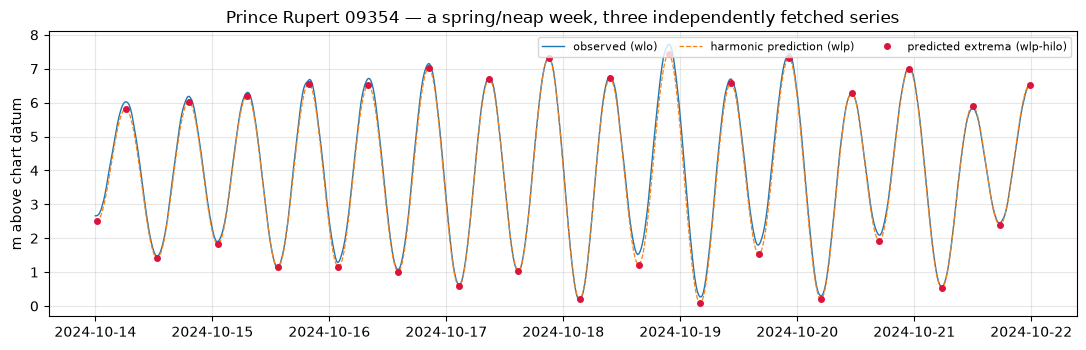

In [32]:
fig, ax = plt.subplots(figsize=(11, 3.6))
week = slice("2024-10-14", "2024-10-21")
ax.plot(obs.loc[week].index, obs.loc[week].values, lw=1.0, label="observed (wlo)")
ax.plot(pred.loc[week].index, pred.loc[week].values, lw=0.9, ls="--",
        label="harmonic prediction (wlp)")
ev = extrema.loc[week]
ax.plot(ev.index, ev.values, "o", ms=4, color="crimson", label="predicted extrema (wlp-hilo)")
ax.set_ylabel("m above chart datum")
ax.set_title("Prince Rupert 09354 — a spring/neap week, three independently fetched series")
ax.legend(loc="upper right", fontsize=8, ncols=3)
plt.tight_layout(); plt.show()

1.95 highs per day, predicted extrema landing a median of 6 minutes from an observed peak, and
7.54 m between the lowest and highest water in two months. This is Prince Rupert's tide, on the
right datum, on the right clock. Three separately requested series agreeing this closely is the
end-to-end check that the times, the units and the datum are all right rather than merely
parseable.

## 13. Time series 2: the non-tidal residual, and what drives it

Subtracting the harmonic prediction from the observation leaves everything the tide does not
explain: storm surge, wind setup, atmospheric pressure — and any freshwater buoyancy signal, if
one exists.

In [33]:
residual = (obs - pred).dropna()
print(f"n = {len(residual)} at 15 min")
print(f"residual   mean {residual.mean():+.3f} m   sd {residual.std():.3f} m   "
      f"range {residual.min():+.3f} to {residual.max():+.3f} m")
print(f"observed vs predicted r = {obs.corr(pred):.5f}")
print(f"the residual is {100 * residual.var() / obs.var():.1f}% of the observed water-level "
      f"variance")

n = 5953 at 15 min
residual   mean +0.078 m   sd 0.118 m   range -0.218 to +0.435 m
observed vs predicted r = 0.99721
the residual is 0.6% of the observed water-level variance


**99.4% of the water-level variance in Prince Rupert harbour is astronomical tide.** Everything
else — every storm of the autumn, every millimetre of the 797 mm of rain — lives in the
remaining 0.6%, a residual with a standard deviation of 12 cm inside a 7.5 m range.

That is the answer to "how does it interact with the tide": it does not compete with it. Any
water-quality signal I hope to see at this site will be modulated by a tide two orders of
magnitude larger in variance, which means the mooring must sample fast enough to resolve the
semidiurnal cycle before anything else can be separated from it.

So what *does* drive the residual? Atmospheric pressure, mostly — the ocean acts as an inverted
barometer, rising about 1 cm for every hPa the pressure falls.

In [34]:
residual_hourly = residual.resample("1h").mean()
fit = pd.concat({"residual": residual_hourly, "pressure": p_eccc}, axis=1).dropna()
design = np.vstack([fit.pressure.to_numpy(), np.ones(len(fit))]).T
slope, intercept = np.linalg.lstsq(design, fit.residual.to_numpy(), rcond=None)[0]

print(f"n = {len(fit)} hourly pairs (DFO water level x ECCC pressure)")
print(f"slope     = {slope * 100:+.2f} cm/hPa   (theoretical inverse barometer: -1.01)")
print(f"r         = {fit.residual.corr(fit.pressure):+.3f}")
print(f"explains  {100 * fit.residual.corr(fit.pressure) ** 2:.0f}% of the residual variance")

n = 1131 hourly pairs (DFO water level x ECCC pressure)
slope     = -1.17 cm/hPa   (theoretical inverse barometer: -1.01)
r         = -0.841
explains  71% of the residual variance


**-1.17 cm/hPa, r = -0.84.** The textbook inverse-barometer response is -1.01 cm/hPa; a coastal
station overshoots because the low-pressure systems that lower the barometer also blow onshore
and pile water up. Recovering it from two agencies' archives joined by a library I did not
write is the strongest evidence I have that the join is sound.

And it *is* a test of the join, not just of physics. If the two series were misaligned in time —
by an hour, or by the seven-hour UTC-to-Pacific offset that is the classic way to get this
wrong — the fit would degrade. Deliberately shifting one side shows how sharp the optimum is:

In [35]:
print("  shift applied to the pressure series      slope        r")
for shift in (-8, -7, -2, -1, 0, 1, 2, 7, 8):
    pair = pd.concat({"residual": residual_hourly, "pressure": p_eccc.shift(shift)},
                     axis=1).dropna()
    A = np.vstack([pair.pressure.to_numpy(), np.ones(len(pair))]).T
    s = np.linalg.lstsq(A, pair.residual.to_numpy(), rcond=None)[0][0]
    marker = "  <-- as fetched" if shift == 0 else ""
    print(f"    {shift:+3d} h                             {s * 100:+6.2f} cm/hPa  "
          f"{pair.residual.corr(pair.pressure):+.3f}{marker}")

  shift applied to the pressure series      slope        r
     -8 h                              -1.03 cm/hPa  -0.739
     -7 h                              -1.06 cm/hPa  -0.764
     -2 h                              -1.17 cm/hPa  -0.841
     -1 h                              -1.17 cm/hPa  -0.844
     +0 h                              -1.17 cm/hPa  -0.841  <-- as fetched
     +1 h                              -1.15 cm/hPa  -0.832
     +2 h                              -1.13 cm/hPa  -0.817
     +7 h                              -0.96 cm/hPa  -0.695
     +8 h                              -0.92 cm/hPa  -0.665


|r| is 0.841 on the series exactly as fetched, peaks marginally higher at 0.844 one hour to one
side, and falls away to 0.764 and 0.695 at -7 and +7 hours. So the two archives sit within about
an hour of true simultaneity — which for a scoping exercise is the whole ballgame, because it
means I can trust a cross-source lag analysis at a resolution finer than the thing I am looking
for. A join that had gone wrong by a timezone would have shown up here as a slope near
-1.0 cm/hPa with |r| in the 0.7s: still a plausible-looking answer, quietly worse.

## 14. Time series 3: does rainfall show up in the harbour at all?

The direct test. If rain produced a detectable freshwater signal in the harbour, I would expect
it to appear either as a buoyancy contribution to the residual (a few centimetres, lagged by a
day or two while the catchments drain) or in the offshore water column.

Lagged cross-correlation of daily rainfall against the daily mean residual, and against the
100 m Chatham Sound temperature as a negative control:

In [36]:
rain = daily["precipitation_amount@1066482:weather_daily"]                 # local-calendar daily total
residual_daily = residual.resample("1D").mean()
deep_daily = deep_temp.resample("1D").mean()

lags = range(-3, 7)
rows = []
for lag in lags:
    r1 = pd.concat({"rain": rain, "x": residual_daily.shift(-lag)}, axis=1).dropna()
    r2 = pd.concat({"rain": rain, "x": deep_daily.shift(-lag)}, axis=1).dropna()
    rows.append({"lag_days": lag, "n": len(r1),
                 "r_residual": round(r1.rain.corr(r1.x), 3),
                 "r_deep_100m": round(r2.rain.corr(r2.x), 3)})
lag_table = pd.DataFrame(rows)
print(lag_table.to_string(index=False))
print(f"\nstrongest |r| with the residual : {lag_table.r_residual.abs().max():.3f}")
print(f"strongest |r| with 100 m temp   : {lag_table.r_deep_100m.abs().max():.3f}")

 lag_days  n  r_residual  r_deep_100m
       -3 60      -0.142       -0.032
       -2 61      -0.240       -0.080
       -1 62      -0.175       -0.148
        0 63       0.207       -0.124
        1 62       0.085       -0.141
        2 61      -0.141       -0.123
        3 60      -0.061       -0.090
        4 59       0.233       -0.086
        5 58      -0.053       -0.108
        6 57      -0.116       -0.091

strongest |r| with the residual : 0.240
strongest |r| with 100 m temp   : 0.148


The two series over the whole window, so the absence is visible rather than merely tabulated —
big rain days and residual peaks do not line up:

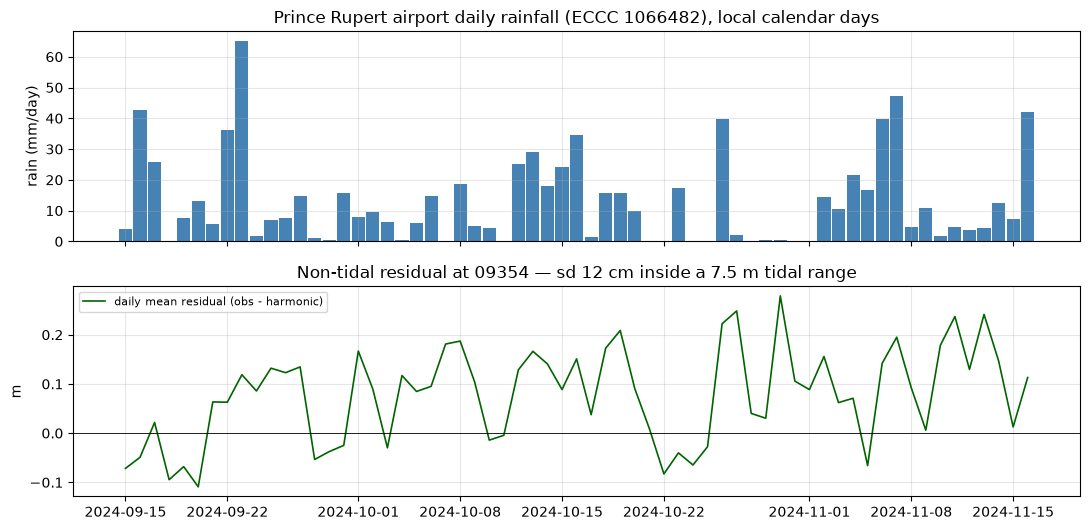

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
axes[0].bar(rain.index, rain.values, width=0.9, color="steelblue")
axes[0].set_ylabel("rain (mm/day)")
axes[0].set_title("Prince Rupert airport daily rainfall (ECCC 1066482), local calendar days")
axes[1].plot(residual_daily.index, residual_daily.values, lw=1.2, color="darkgreen",
             label="daily mean residual (obs - harmonic)")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_ylabel("m")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].set_title("Non-tidal residual at 09354 — sd 12 cm inside a 7.5 m tidal range")
plt.tight_layout(); plt.show()

**No.** The strongest correlation at any lag from -3 to +6 days is |r| = 0.240, at a lag of
-2 days on 61 daily pairs — the wrong sign for a freshet, the wrong direction in time for
causation, and with no coherent shape across lags. The residual is doing its own thing, and
section 13 says what that is: pressure, at r = -0.84.

The 100 m control behaves as it should — |r| never exceeds 0.15 — which is what you want from a
control. Rain does not reach 100 m in Chatham Sound over two months, and if the analysis had
claimed it did I would distrust everything above it.

Two honest caveats before I write this up as a null result:

* **A residual is a bad freshet detector.** The buoyancy contribution of even a large coastal
  freshwater plume to *water level* is millimetres to a couple of centimetres, buried in a
  12 cm residual dominated by weather. This experiment can only rule out a large effect.
* **The measurement that would settle it does not exist.** Salinity is what responds to
  freshet, and section 3 established there is no salinity record within 50 km after 2019.

Which is the argument for the mooring, stated with numbers: the harbour's freshwater response
is unobservable in public archives, not absent from them.

## 15. Time series 4: was this a normal autumn?

A two-month window is only worth generalising from if it was not freakish. ECCC's monthly
summaries go back to 1994 at Mont Circle and to 2010 at the airport, and the older station also
carries the published 1981–2010 normal alongside each observation.

In [38]:
monthly = (omnisea.discover(sites=PRINCE_RUPERT, time=("1994-01-01", "2025-01-01"),
                            providers="eccc_climate_monthly")
           .filter(station_id=["1066482", "1066488"])
           .fetch())

rows = []
for node_path, label in [("/in_situ/weather_monthly/1066482", "PRINCE RUPERT (airport)"),
                         ("/in_situ/weather_monthly/1066488", "PRINCE RUPERT MONT CIRC")]:
    ds = monthly[node_path].dataset
    series = ds["precipitation_amount"].to_series().dropna()
    normals = (ds["precipitation_amount_normal"].to_series()
               if "precipitation_amount_normal" in ds else None)
    for month, name in [(9, "Sep"), (10, "Oct"), (11, "Nov")]:
        same_month = series[series.index.month == month]
        history = same_month[same_month.index.year < 2024]
        this_year = same_month[same_month.index.year == 2024]
        if this_year.empty:
            continue
        value = float(this_year.iloc[0])
        rows.append({
            "station": label, "month": name, "mm_2024": value,
            "n_years": len(history),
            "mean_mm": round(float(history.mean()), 1),
            "sd_mm": round(float(history.std()), 1),
            "z": round((value - history.mean()) / history.std(), 2),
            "normal_1981_2010": (round(float(normals[normals.index.month == month].dropna()
                                             .iloc[0]), 1)
                                 if normals is not None and normals.notna().any() else None),
        })
print(pd.DataFrame(rows).to_string(index=False))

                station month  mm_2024  n_years  mean_mm  sd_mm    z  normal_1981_2010
PRINCE RUPERT (airport)   Sep    314.6       14    221.8  122.2 0.76               NaN
PRINCE RUPERT (airport)   Oct    307.0       14    222.3   87.5 0.97               NaN
PRINCE RUPERT (airport)   Nov    338.3       14    274.1  107.9 0.59               NaN
PRINCE RUPERT MONT CIRC   Sep    460.8       22    262.3  132.5 1.50             296.5
PRINCE RUPERT MONT CIRC   Oct    446.2       22    338.9  156.2 0.69             431.7
PRINCE RUPERT MONT CIRC   Nov    368.2       23    322.5  134.7 0.34             375.5


Wet, but not extraordinary. At the airport, October 2024 delivered 307.0 mm against a mean of
222.3 mm over the 14 previous Octobers — **z = +0.97** — and September (z = +0.76) and November
(z = +0.59) were on the wet side of normal without being records. At Mont Circle, whose record
runs back to 1994, October 2024's 446.2 mm sits at **z = +0.69** against a 22-year mean of
338.9 mm, and almost exactly on the published 1981–2010 normal of 431.7 mm. Only September at
Mont Circle stands out, at z = +1.50.

(The airport has no `normal_1981_2010` because the station only opened in 2010 — ECCC publishes
no normal for it, and omnisea returns the NaN rather than borrowing a neighbour's. Mont Circle,
which does have one, is the station to use for anomalies.)

So my window is a representative wet autumn — between a third and one and a half standard
deviations wetter than usual depending on gauge and month — and the null result in section 14 is
not the result of a dry spell. Note again the gauge disagreement: the same month, at two gauges
about 6 km apart, 307 mm versus 446 mm. Whichever gauge a freshwater budget uses changes the
answer by nearly 50%.

## 16. What I will actually propose

**Answering the question I started with:**

* Rain on the north coast does **not** show up in Prince Rupert harbour water level as anything
  I can detect. The best cross-correlation between daily rainfall and the non-tidal residual, at
  any lag from -3 to +6 days, is |r| = 0.240 on 61 daily pairs.
* The residual is driven by atmospheric pressure at **-1.17 cm/hPa (r = -0.84)** — a clean
  inverse-barometer response, recovered from two agencies' archives joined on one time axis.
* The tide is **99.4% of the water-level variance**, range 7.54 m in two months. Nothing at this
  site is separable from it without sampling that resolves the semidiurnal cycle.
* **There is no public measurement of freshwater input within 50 km for 2024.** River gauges:
  discontinued (Kloiya 2022, Diana Creek 1972). Lightstation salinity: ends 2019-11-30. This is
  the finding that justifies the deployment.

**Design consequences for the mooring:**

1. **Salinity is the instrument that matters**, not water level. The freshet signal is a
   buoyancy and stratification signal; the archives contain neither.
2. **Sample at 10 minutes or faster.** With 99.4% of the variance tidal, anything coarser
   aliases the tide into whatever I am trying to measure.
3. **Site it inshore of the airport gauge.** The 2:1 rainfall gradient across Chatham Sound
   (797 mm at the airport, 367 mm at Triple Island, and a town gauge suggesting more still)
   means the harbour's catchment is wetter than my best rainfall record admits.
4. **Free drivers are already good.** Tide at 15 min and pressure/wind hourly are available,
   validated to the millimetre against upstream, and joinable to a field sheet in one call.
   I do not need to instrument the weather.

## 17. Attribution, and the file

`citation()` builds the attribution block for the methods section out of the result rather than
out of memory — and reports what went wrong, which is the part that stops a partial pull being
published by accident.

In [39]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-27T15:04:58+00:00 from 4 source(s) across 5 station(s), covering 2024-09-15 to 2024-11-16.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2024-09-15 to 2024-11-16): Prince Rupert (09354). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate (1 station(s), 2024-09-15 to 2024-11-16): PRINCE RUPERT (1066482). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate_daily (1 station(s), 2024-09-15 to 2024-11-16): PRINCE RUPERT (1066482). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io

`provenance(by="node")` gives the same thing as a frame, with the exact endpoint each series was
read from — which matters for anything that cannot be recovered later from the query alone:

In [40]:
print(omnisea.provenance(tree, by="node")[
    ["node", "institution", "station_id", "n_time", "source_url"]]
    .to_string(index=False))

                                                                 node                                                              institution                              station_id  n_time                                                                                             source_url
                                                 /in_situ/tides/09354              Fisheries and Oceans Canada / Canadian Hydrographic Service                                   09354    5953      https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/5cebf1de3d0f4a073c4bba06/data?time-series-code=wlo
                                             /predictions/tides/09354              Fisheries and Oceans Canada / Canadian Hydrographic Service                                   09354    5953      https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/5cebf1de3d0f4a073c4bba06/data?time-series-code=wlp
                                        /predictions/tides_hilo/09354              Fisheries and Oceans Canada / Canad

One caveat on that block, for anyone reproducing this: the terms-of-use URL printed for the
ERDDAP-sourced series points at NOAA CoastWatch regardless of which ERDDAP server the data came
from. The Chatham Sound mooring is DFO Institute of Ocean Sciences data read from CIOOS Pacific,
and CoastWatch has nothing to do with it. The `institution` and `license` fields are correct —
they come from the server — but I edited the terms link by hand before quoting it.

Finally, the tree round-trips to netCDF with its group structure and every attribute intact:

In [41]:
import xarray as xr

omnisea.to_netcdf(tree, "prince_rupert.nc")
reopened = xr.open_datatree("prince_rupert.nc")
print("groups with data:",
      len([n for n in reopened.subtree if n.dataset.data_vars]))
print("datum survived:",
      reopened["/in_situ/tides/09354"].dataset.attrs["datum_offset_CGVD2013"])
print("query recorded:", {k: v for k, v in reopened.attrs.items()
                          if k.startswith("query_")})
reopened.close()

groups with data: 8
datum survived: -3.66
query recorded: {'query_start': '2024-09-15T00:00:00+00:00', 'query_end': '2024-11-16T00:00:00+00:00', 'query_bbox': array([-131.09488977,   53.86733982, -129.55311023,   54.76666018]), 'query_site_names': '["Prince Rupert"]', 'query_site_lats': '[54.317]', 'query_site_lons': '[-130.324]', 'query_site_radius_km': '[50]', 'query_providers': 'dfo_tides, eccc_climate, eccc_climate_daily, erddap_tabledap'}


---

### Things that got in my way, for the record

Working through this I hit five things a colleague should know before starting:

1. **`IOS_CUR_Moorings` returns two instruments spliced into one series** (section 5). One row
   per timestamp downstream where ERDDAP served two, alternating between 100 m and 181 m, with
   no warning. Mask on `instrument_depth` before using any ERDDAP mooring node.
2. **ERDDAP catalogue positions are meaningless** (section 4). Datasets are listed at 0.00 km
   with centroid coordinates in the continental interior, so `filter(nearest=1)` and
   `filter(max_distance_km=)` are unusable when an ERDDAP source is in the catalogue. Select by
   `station_id`. The node itself carries the real position and a correct
   `distance_from_site_km`.
3. **Discovery over-promises for discontinued stations** (section 2). Seven dead river gauges
   were advertised with row estimates; `fetch()` returned nothing and said nothing. Only
   `citation()` reports it. Call `citation()` on every tree.
4. **`drop_correlated()` kept heating degree days over measured temperature** (section 11). Use
   `keep=` to pin the quantities you actually want.
5. **Two columns can be the same variable on different day boundaries** (section 10). UTC-day
   sums and local-day totals of the same gauge correlate at only r = 0.79 and differ by 46.6 mm
   over two months. Check `attrs["omnisea_aggregation"]` for *"read in station-local time"*
   before putting two similarly-named columns in one model.

None of those cost me the analysis. All of them would have cost me a number if I had not
looked.